# **Gradient Boosting Classification**

# Gradient Boosting for Classification: Step-by-Step Intuition

**The Core Idea:** Just like in regression, Gradient Boosting for classification builds a sequence of small, weak decision trees. **Each new tree is trained to predict the mistakes (residuals) made by the previous trees.** However, because we are predicting discrete categories (like Yes/No) instead of continuous numbers, we must do our math in **Log-Odds** and convert back and forth to **Probabilities**.


## 1. The Mini Dataset
Let's imagine we are trying to predict if a person likes **Video Games** based on their **Age** and **Gender**. We have a tiny dataset of 4 people.

| Person | Age | Gender | Likes Games (Actual) ($y$) |
| :---: | :---: | :---: | :---: |
| **A** | 15 | Male | Yes (1) |
| **B** | 18 | Male | Yes (1) |
| **C** | 45 | Female | No (0) |
| **D** | 30 | Female | Yes (1) |

*(Note: 3 people like games (1) and 1 person does not (0).*


## Step 1: The Initial Prediction ($F_0$)
Gradient Boosting doesn't start with a tree. It starts with a simple "baseline" guess for everyone. For binary classification, the mathematically optimal initial guess to minimize Log-Loss is the **Log-Odds** of the target variable.

* Odds = (Number of Yes) / (Number of No) = 3 / 1 = 3
* **Initial Log-Odds ($F_0$)** = $\ln(3) \approx \mathbf{1.1}$

Because we can't easily calculate errors directly against a "Log-Odds" number, we convert this into a **Probability ($p$)** using the standard logistic (sigmoid) function:
* $p = \frac{e^{1.1}}{1 + e^{1.1}} \approx \mathbf{0.75}$ (or 75%)

Let's update our table with this initial prediction ($F_0$):

| Person | Actual ($y$) | Initial Log-Odds ($F_0$) | Initial Probability ($p_0$) |
| :---: | :---: | :---: | :---: |
| **A** | 1 | 1.1 | 0.75 |
| **B** | 1 | 1.1 | 0.75 |
| **C** | 0 | 1.1 | 0.75 |
| **D** | 1 | 1.1 | 0.75 |


## Step 2: Calculate the Errors (Residuals)
Now, the algorithm evaluates how bad its initial probability guess was. It calculates the **pseudo-residuals** (errors) for each person. 
*Formula:* `Residual = Actual - Predicted Probability`

| Person | Actual ($y$) | Probability ($p_0$) | **Residual 1 ($r_1$)** |
| :---: | :---: | :---: | :---: |
| **A** | 1 | 0.75 | **0.25** |
| **B** | 1 | 0.75 | **0.25** |
| **C** | 0 | 0.75 | **-0.75** |
| **D** | 1 | 0.75 | **0.25** |

*(Notice: Person C who does not like games has a negative residual, meaning our 75% probability guess was way too high for them).*


## Step 3: Train the First Decision Tree ($Tree_1$)
Here is the magic: **We build a Decision Tree to predict `Residual 1`.** 

The tree looks at Age and Gender and tries to group similar residuals together. It splits the data to figure out: *"What patterns explain our previous probability errors?"* 

```text
                     [Age <= 40 ?]
                    /             \
                 Yes               No
                /                    \
             Leaf 1                 Leaf 2
    (Persons A, B, D)              (Person C)
  Residuals: 0.25, 0.25, 0.25      Residual: -0.75
```

**Crucial Math Difference from Regression:** We CANNOT simply output the average of the residuals in the leaf like we do in regression. Because our base predictions are in *Log-Odds*, but our residuals are derived from *Probabilities*, we must use a transformation formula to get a **Log-Odds Output Value ($\gamma$)** for the leaf.

*Transformation Formula for a Leaf:*   
$$ \gamma = \frac{\sum \text{Residuals}}{\sum [ \text{Previous Prob} \times (1 - \text{Previous Prob}) ]} $$

Let's do the math for **Leaf 2 (Person C)**:
* Sum of Residuals = -0.75
* Denominator = $0.75 \times (1 - 0.75) = 0.1875$
* Tree Output ($\gamma$) for Leaf 2 = $-0.75 / 0.1875 =$ **-4.0**

*(For Leaf 1, doing the same math yields an output of approximately **+1.33**).*


## Step 4: Update the Predictions ($F_1$)
Now we update our initial prediction. Because we are making updates in the **Log-Odds space**, we add the new tree's transformed output to our old *Log-Odds*, multiplied by a **Learning Rate ($\eta$)** (let's use **`0.1`**).

*Formula:*  **`New Log-Odds = Old Log-Odds + (Learning Rate × Tree Output)`**

Let's calculate the new prediction ($F_1$) for **Person C**:
* $F_1 \text{ (Log-Odds)} = 1.1 + (0.1 \times -4.0)$ 
* $F_1 \text{ (Log-Odds)} = 1.1 - 0.4 =$ **0.7**

To see if we improved, we convert this new Log-Odds back into a **New Probability ($p_1$)**:
* $p_1 = \frac{e^{0.7}}{1 + e^{0.7}} \approx \mathbf{0.67}$ (or 67%)

Let's update the table for everyone:

| Person | Actual ($y$) | Old Log-Odds | Tree 1 Output ($\gamma$) | **New Log-Odds ($F_1$)** | New Prob ($p_1$) | **New Residual 2** ($y - p_1$) |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **A** | 1 | 1.1 | 1.33 | $1.1 + (0.1 \times 1.33) =$ **1.23** | **0.77** | $1 - 0.77 =$ **0.23** |
| **B** | 1 | 1.1 | 1.33 | $1.1 + (0.1 \times 1.33) =$ **1.23** | **0.77** | $1 - 0.77 =$ **0.23** |
| **C** | 0 | 1.1 | -4.0 | $1.1 + (0.1 \times -4.0) =$ **0.7** | **0.67** | $0 - 0.67 =$ **-0.67** |
| **D** | 1 | 1.1 | 1.33 | $1.1 + (0.1 \times 1.33) =$ **1.23** | **0.77** | $1 - 0.77 =$ **0.23** |

**Look at the New Probabilities!** 
Our probability prediction for Person C (who does NOT like games) went down from `75%` to `67%`. Our error shrank mathematically from `-0.75` to `-0.67`. 
Our probability prediction for Persons A, B, and D (who DO like games) went up from `75%` to `77%`.
*We just took a small "step" in the right direction for every single person!*


## Step 5: Repeat (The "Boosting" phase)
We repeat steps 2, 3, and 4. 
1. We take **Residual 2** (the new probability errors).
2. We build **Tree 2** to group and predict *those* specific errors.
3. We calculate the transformation $\gamma$ for the new leaves.
4. We update the Log-Odds again: $F_2 = F_1 + (0.1 \times Tree_2)$
5. We convert the new Log-Odds back to probabilities to get Residual 3.

With every single tree we add, the probabilities will push closer to 1.0 for the people who like games, and closer to 0.0 for those who don't.


## The Final Mathematical Equation

If we build 100 trees, our final prediction for a new person looks like this:

$$ \text{Final Log-Odds} = \text{Initial Log-Odds} + \eta(Tree_1) + \eta(Tree_2) + \dots + \eta(Tree_{100}) $$

Or written more formally:

$$ F_M(x) = F_0(x) + \sum_{m=1}^{M} \eta \cdot \gamma_m(x) $$

*(Where $F_0$ is the base log-odds, $\eta$ is learning rate, and $\gamma_m$ are the transformed leaf outputs of the individual decision trees).*

#### Converting to the Final Answer
The equation above gives us the **Final Log-Odds**. Because end-users want a probability (and ultimately a Yes/No class), we do one final conversion step using the sigmoid function:

$$ P(Y=1|x) = \frac{e^{F_M(x)}}{1 + e^{F_M(x)}} $$

If this final probability is $> 0.5$, we predict **Yes (1)**. Otherwise, we predict **No (0)**.

### Putting it all together into an English sentence for Classification:
> **"To predict if someone likes games, start with the base Log-Odds of the whole dataset ($F_0$), then loop through every single decision tree we built ($\sum$). For each tree, find the transformed Log-Odds output for that person's leaf ($\gamma_m$), shrink it down by a small learning rate ($\eta$), and add it to our running total. Finally, run that total Log-Odds through a sigmoid function to get a clean probability between 0 and 1."**

### Summary of Intuition
Gradient Boosting for Classification is essentially the exact same machinery as Regression. The only trick is that we are forced to build our trees to predict *Probability Error*, but we are forced to update our running totals in *Log-Odds*. The transformation formula inside the leaves ($\gamma$) is the mathematical bridge that allows these two different worlds to work together perfectly.



In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import mean_squared_error, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
X_data, y_data = make_classification(
    n_samples=1000,
    n_features=5,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=42
)

df = pd.DataFrame(X_data, columns=[f'feature_{i}' for i in range(5)])
df['target'] = y_data


X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,target
0,0.789678,0.875056,-0.524088,1.108592,-1.402916,0
1,-1.686931,3.324227,-0.190503,3.101080,-3.083091,2
2,-1.070137,2.950171,0.508269,2.853285,-2.940819,2
3,0.103687,-1.319036,-1.352670,-1.364504,1.494486,1
4,-1.309502,1.750843,-0.557423,1.533576,-1.422048,2


In [3]:
# making the model
gbc = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    random_state=42,
    max_depth=5,
    loss='log_loss',
    # alpha=0.9,            # classifier doesn't take alpha
    n_iter_no_change=10,
    validation_fraction=0.2,
    tol=0.001
)

# training the model
gbc.fit(X_train, y_train)
y_pred = gbc.predict(X_test)

print(f"MSE : {mean_squared_error(y_test, y_pred)}")
print(f"ACCURACY : {accuracy_score(y_test, y_pred)}")

print(f"The model stopped training after {gbc.n_estimators_} iterations.")


MSE : 0.155
ACCURACY : 0.905
The model stopped training after 35 iterations.


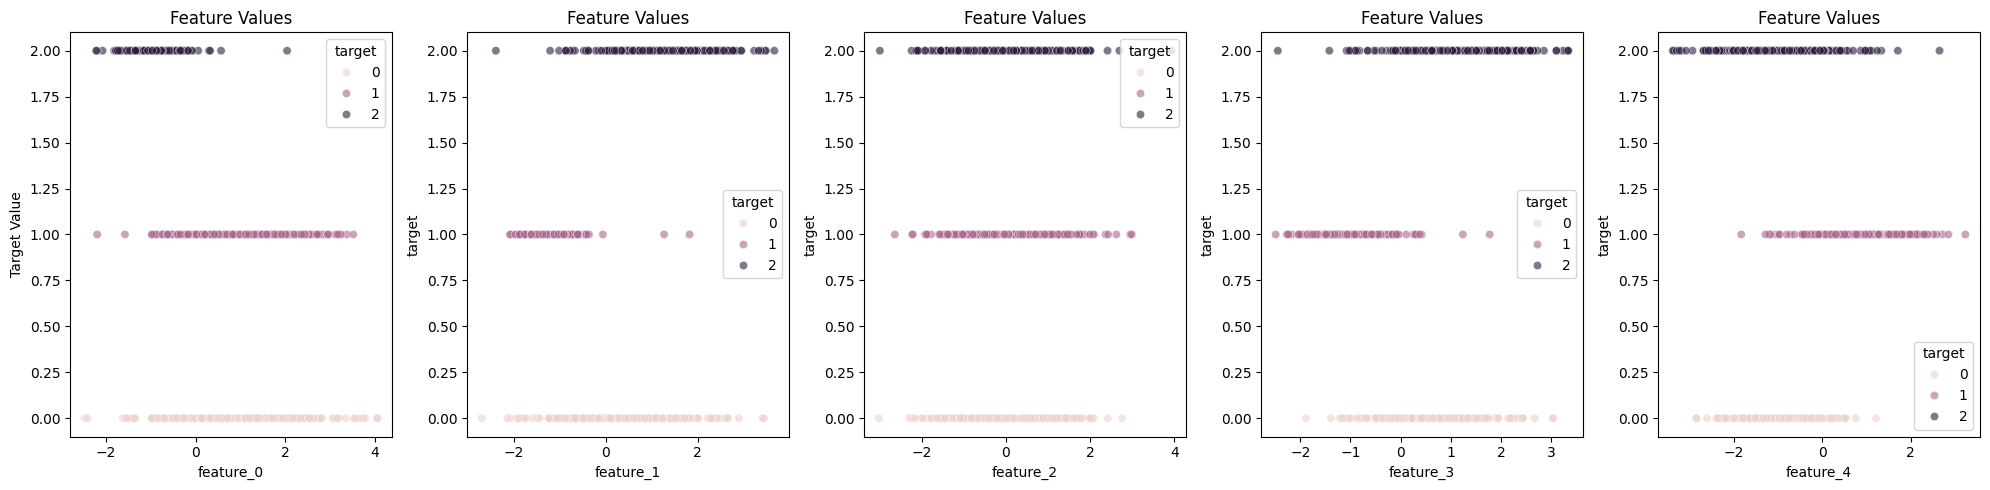

In [4]:
# plotting the graph

train_df = X_train.copy()
train_df['target'] = y_train

fig, axes = plt.subplots(1,5,figsize=(20,5))

for i, col in enumerate(X.columns):
    sns.scatterplot(ax=axes[i], x=train_df[col], y=train_df['target'], alpha=0.6, hue=train_df['target'])
    axes[i].set_title(f"{col} vs Target")
    axes[i].set_title(f"Feature Values")

    if i == 0:
        axes[i].set_ylabel('Target Value')

plt.tight_layout()
plt.show()

FEATURE IMPORTANCE : 
feature_0    0.504416
feature_1    0.300310
feature_2    0.023170
feature_3    0.033909
feature_4    0.138194
dtype: float64


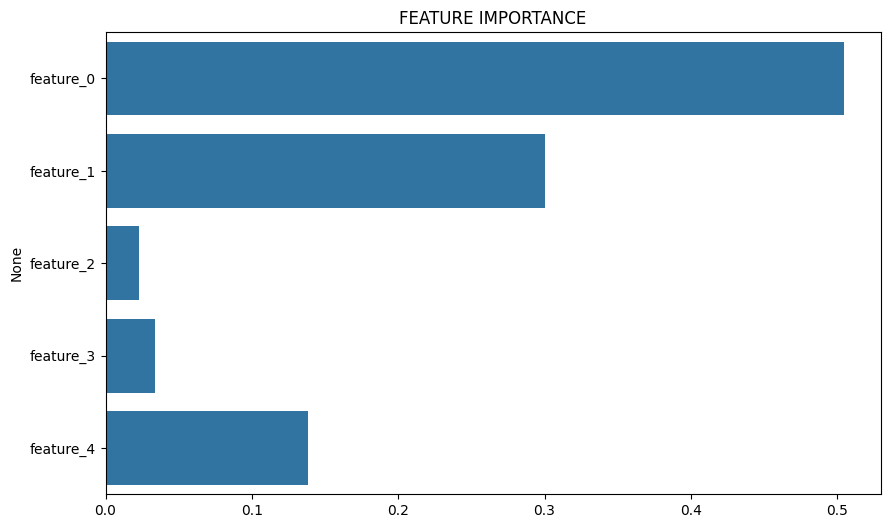

In [5]:
# checking for feature importance
print(f"FEATURE IMPORTANCE : \n{pd.Series(gbc.feature_importances_, index=X.columns)}")

plt.figure(figsize=(10,6))
sns.barplot(x=gbc.feature_importances_, y=X.columns)
plt.title("FEATURE IMPORTANCE")
plt.show()

In [6]:
!nvidia-smi

Thu Mar  5 03:37:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----